<a href="https://colab.research.google.com/github/Daniel210492/Daniel210492/blob/main/Proyecto_Introducci%C3%B3n_al_An%C3%A1lisis_Estad%C3%ADstico_penguins.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROYECTO: INTRODUCCIÓN AL ANÁLISIS ESTADÍSTICO**

Una vez visto el ***Módulo 2: Fundamentos Estadísticos***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **análisis exploratorio con aprendizaje estadístico** de cualquier dataset proveniente de la librería de ***Seaborn*** que no haya sido utilizado.

Se sugiere los siguientes puntos para llevar a cabo lo anterior:

*   Realizar un **análisis descriptivo** para comprender comportamiento de la descripción de los datos a través de resúmenes.
*   Realizar un **aprendizaje estadístico** para predecir comportamientos lineales de datos a través de la regresión lineal simple.

In [3]:
#importamos librerias que seran necesarias para el analisis:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
#Se selecciona el dataset penguins ya que tiene datos nulos y datos faltantes
#se carga desde seaborn.
df_penguins = sns.load_dataset('penguins')
df_penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [6]:
#revisamos el resumen de cada columna para determinar el tipo de datos
#Asi como un primer vistazo a los valores nulos
df_penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [7]:
df_penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [9]:
#Identificamos valores nulos en 5 columnas
#island, bill_lenght_mm, bill_depth_mm, flipper_lenght_mm, body_mass_g y sex
#Determinaremos que tratamiento se le realizara a cada una

df_penguins.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


In [11]:
#dado los valores nulos, eliminaremos todos los que son 2, en sex se sustuiran por la moda
#se opta por la moda por que es un valor categorico
moda_sex = df_penguins["sex"].mode()[0]

df_penguins["sex"] = df_penguins["sex"].fillna(moda_sex)

In [12]:
df_penguins = df_penguins.dropna()

Se identificaron valores nulos en distintas columnas del dataset.
Debido a que las variables numéricas (bill_length_mm, bill_depth_mm, flipper_length_mm y body_mass_g) contenían únicamente 2 registros faltantes de un total de 344 observaciones, se decidió eliminar dichos registros al representar un porcentaje mínimo del dataset.

En la variable categórica sex, se encontraron 11 valores nulos. Para conservar la mayor cantidad posible de información, estos fueron imputados utilizando la moda de la columna, es decir, el valor más frecuente.

In [13]:
#revisamos nuevamente nuestros valores nulos
df_penguins.isnull().sum()

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


In [14]:
#Hacemos nuevamente nuestros analisis descriptivos con .info, .describe

df_penguins.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            342 non-null    object 
 1   island             342 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                342 non-null    object 
dtypes: float64(4), object(3)
memory usage: 21.4+ KB


In [15]:
df_penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [16]:
df_penguins.head(20)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,Male
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,Male
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,Male


##EDA
Comenzamos el analisis EDA

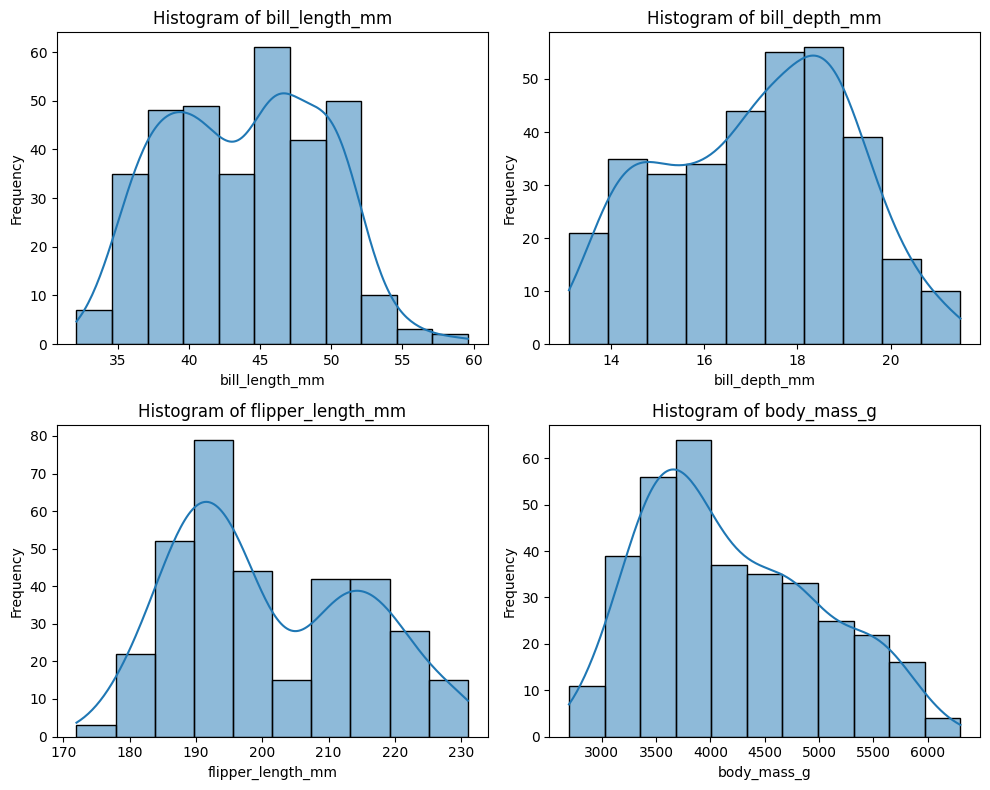

In [19]:
#realizamos histogramas con KDE para ver las distribuciones de vada variable numerica
#Se usa un grid 2x2 para mejor visualizacion

columns_to_plot = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    sns.histplot(data=df_penguins, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

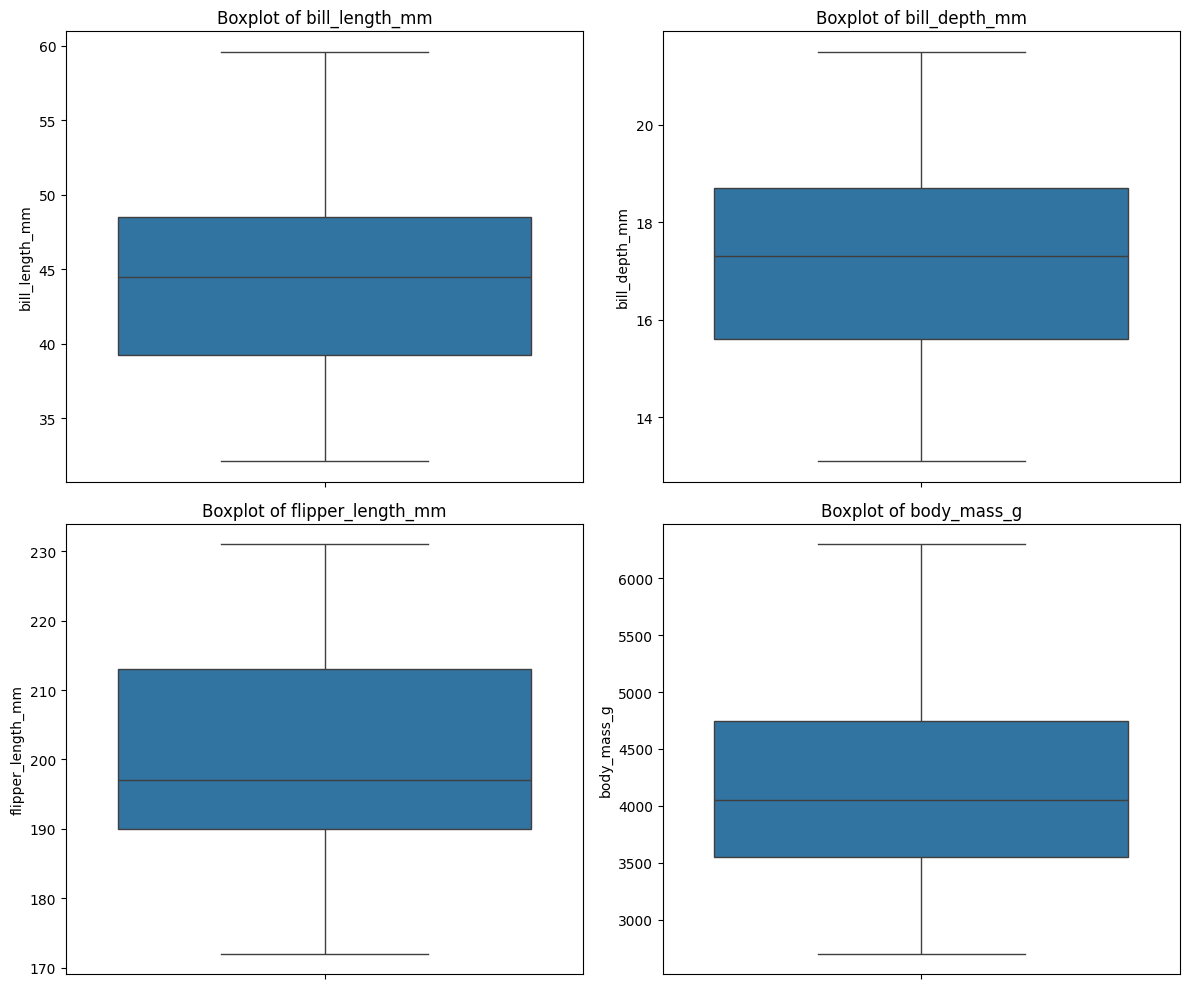

In [20]:
#Revisamos los boxplots en busca de outliers o datos anormales
#Se usa grid 2x2 para mejor visualizacion

columns_to_plot = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    sns.boxplot(data=df_penguins, y=col, ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

Se realizó un análisis visual de las variables numéricas mediante histogramas (histplot) y diagramas de caja (boxplot) con el objetivo de comprender la distribución de los datos y detectar posibles valores atípicos.

A través de los histogramas se observó que las variables presentan distribuciones relativamente consistentes y sin concentraciones anormales de datos. Además, las curvas de densidad permitieron identificar un comportamiento estable en la mayoría de las variables numéricas.

Por otra parte, los diagramas de caja mostraron que no existen valores atípicos significativos (outliers) dentro del dataset. Los datos se encuentran distribuidos de manera uniforme dentro de rangos esperados, sin registros extremos que pudieran afectar negativamente el análisis estadístico o el modelo de regresión lineal.

Debido a ello, no fue necesario aplicar tratamientos adicionales para manejo de outliers, permitiendo conservar la integridad original de los datos para las siguientes etapas del análisis exploratorio y aprendizaje estadístico.

##Exploracion de variables categoricas


In [22]:
#Vamos a revisar las variables, island, sex, y species.
#Primero veamos que datos tenemos para cada 1
print(df_penguins["species"].unique())
print(df_penguins["island"].unique())
print(df_penguins["sex"].unique())

['Adelie' 'Chinstrap' 'Gentoo']
['Torgersen' 'Biscoe' 'Dream']
['Male' 'Female']


In [23]:
#Vamos a contar la frecuencia con las que cada una aparece
print(df_penguins["species"].value_counts())
print(df_penguins["island"].value_counts())
print(df_penguins["sex"].value_counts())

species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64
island
Biscoe       167
Dream        124
Torgersen     51
Name: count, dtype: int64
sex
Male      177
Female    165
Name: count, dtype: int64


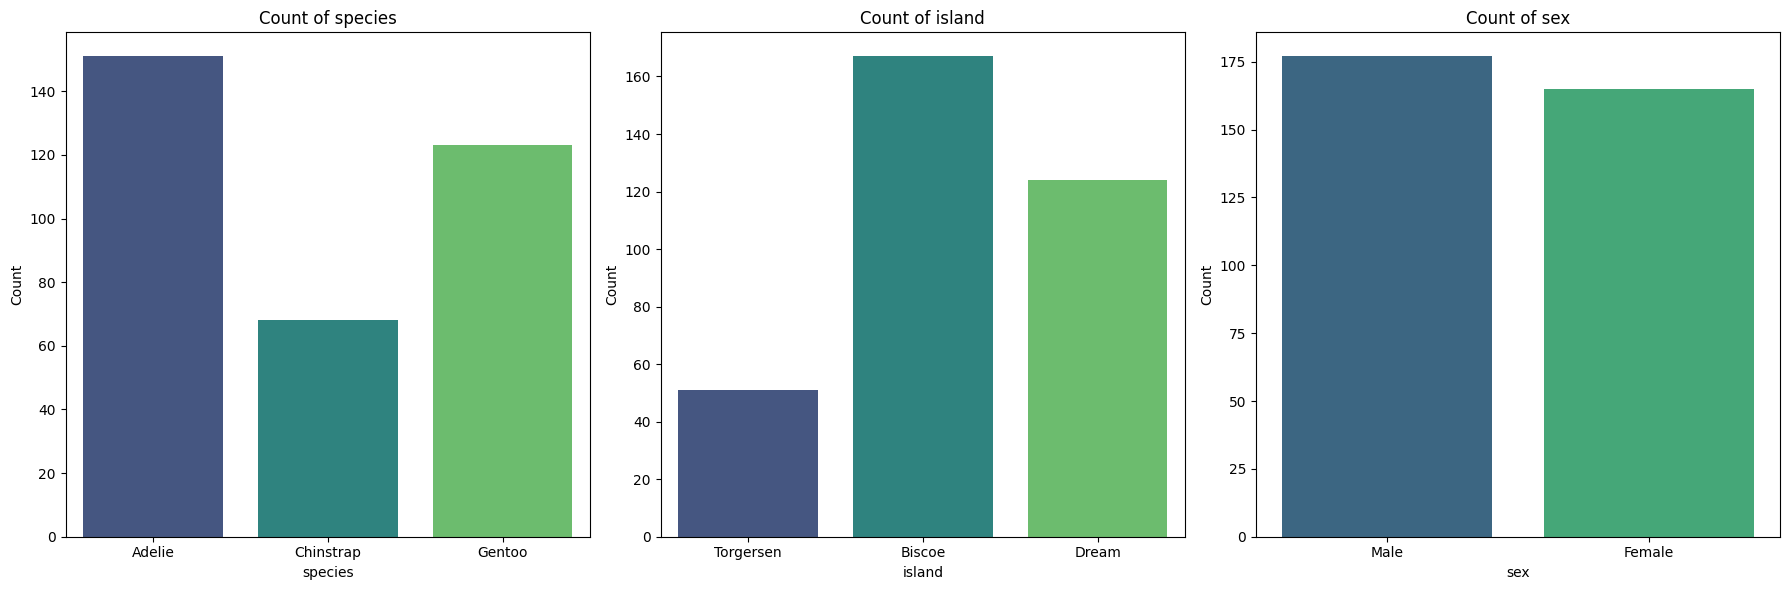

In [29]:
#realizmaos las graficas de countplot para visualizar las variables categoricas

categorical_cols = ['species', 'island', 'sex']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df_penguins, x=col, ax=axes[i], palette='viridis', hue=col, legend=False)
    axes[i].set_title(f'Count of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

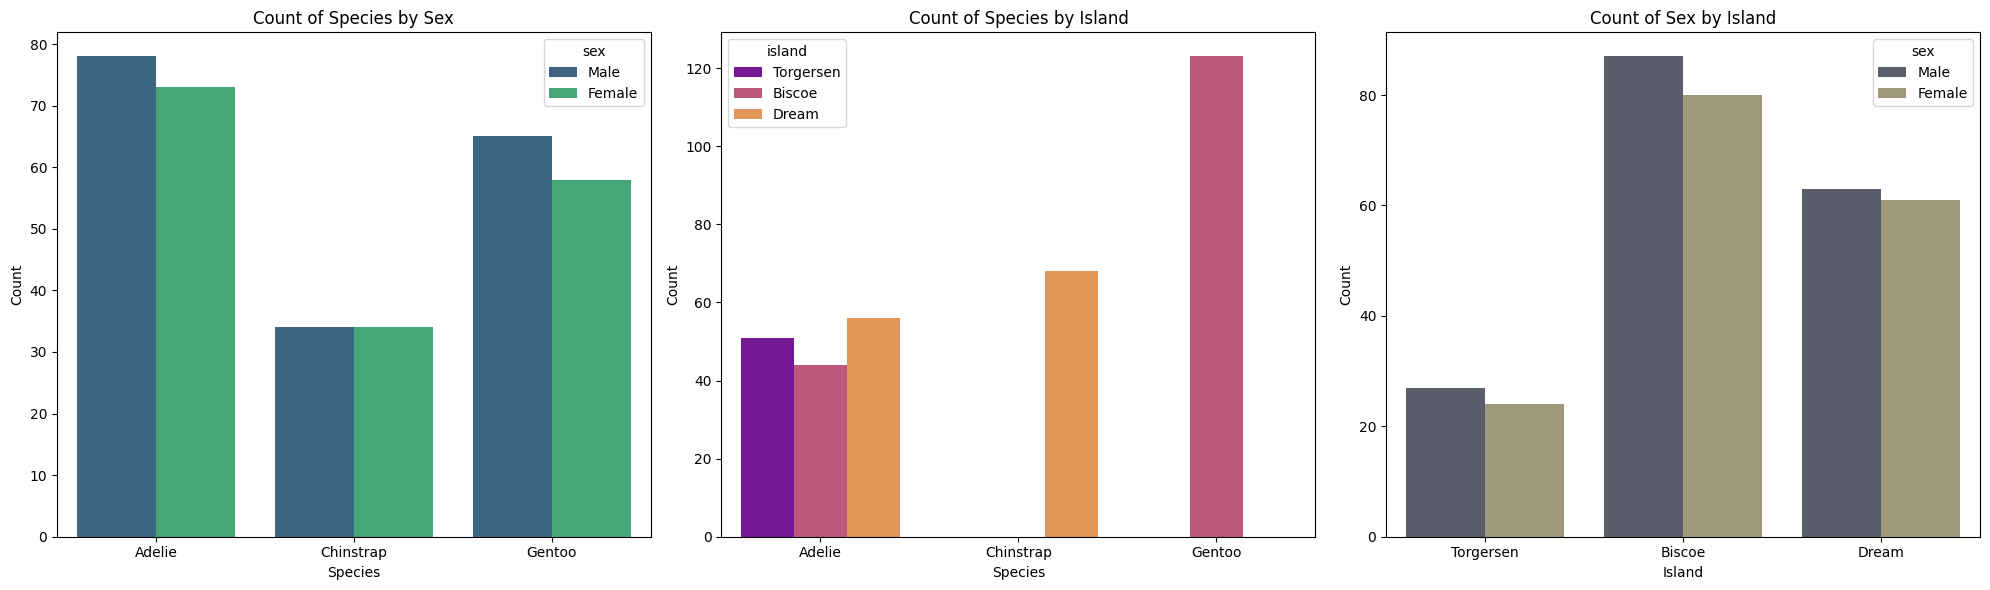

In [27]:
#tambien realizaremos countplots cruzados para ver como se relaciona cada variable


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

# Countplot for species by sex
sns.countplot(data=df_penguins, x='species', hue='sex', ax=axes[0], palette='viridis')
axes[0].set_title('Count of Species by Sex')
axes[0].set_xlabel('Species')
axes[0].set_ylabel('Count')

# Countplot for species by island
sns.countplot(data=df_penguins, x='species', hue='island', ax=axes[1], palette='plasma')
axes[1].set_title('Count of Species by Island')
axes[1].set_xlabel('Species')
axes[1].set_ylabel('Count')

# Countplot for sex by island
sns.countplot(data=df_penguins, x='island', hue='sex', ax=axes[2], palette='cividis')
axes[2].set_title('Count of Sex by Island')
axes[2].set_xlabel('Island')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

Se realizó un análisis de las variables categóricas del dataset utilizando tablas de frecuencia y gráficos de conteo (countplot).

A partir de este análisis se observó la distribución de las diferentes especies de pingüinos, las islas donde fueron registrados y la proporción de individuos según su sexo.

Se identificó una mayor prevalencia de ejemplares machos en la mayoría de las especies; sin embargo, en la especie Chinstrap la distribución entre machos y hembras se visualiza más equilibrada.

Asimismo, se observó que únicamente la especie Adelie se encuentra presente en todas las islas del dataset, mientras que las demás especies presentan una distribución más limitada geográficamente.

Las visualizaciones permitieron comprender mejor la composición y comportamiento de las variables categóricas, así como detectar patrones de distribución entre especies, sexo e islas antes de avanzar hacia el análisis predictivo mediante regresión lineal.

--- Matriz de correlación para variables numéricas ---


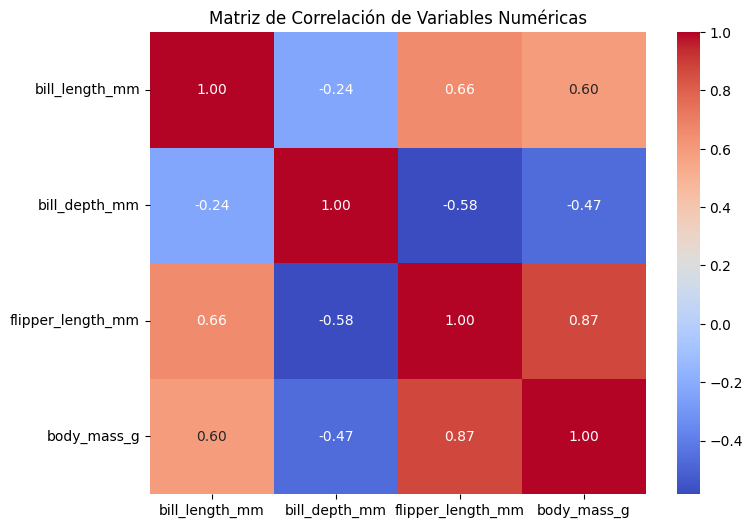


--- Scatterplots para variables numéricas con 'species' como diferenciador ---


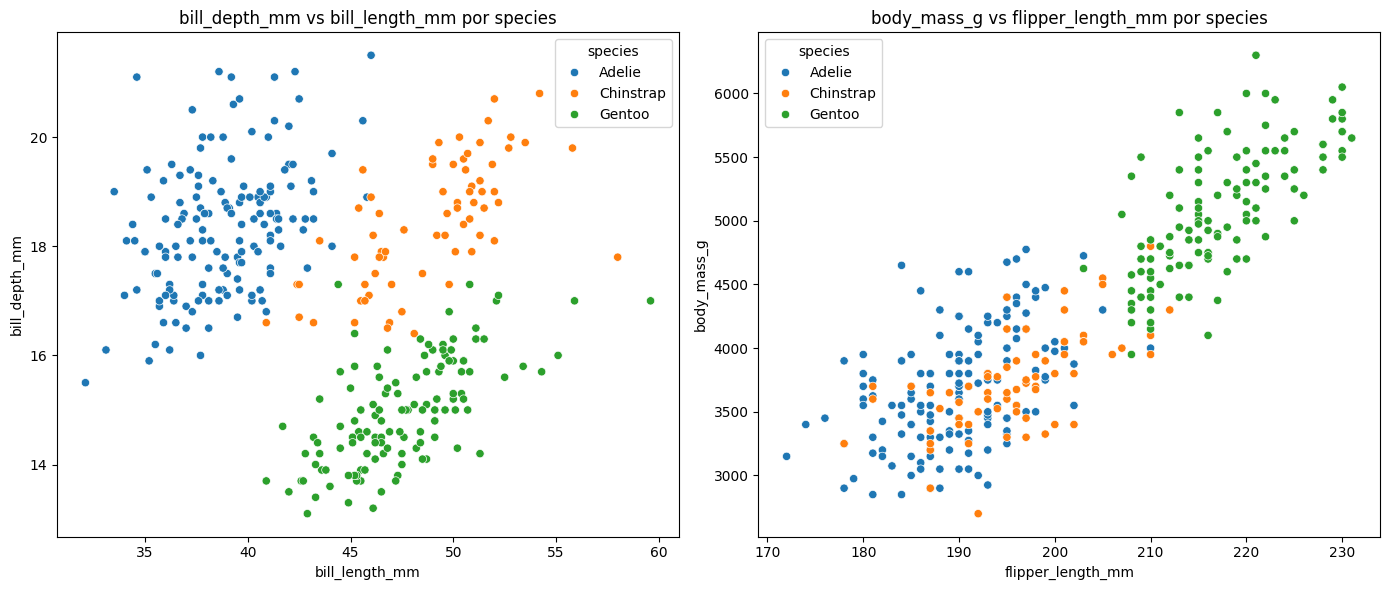


--- Scatterplots para variables numéricas con 'island' como diferenciador ---


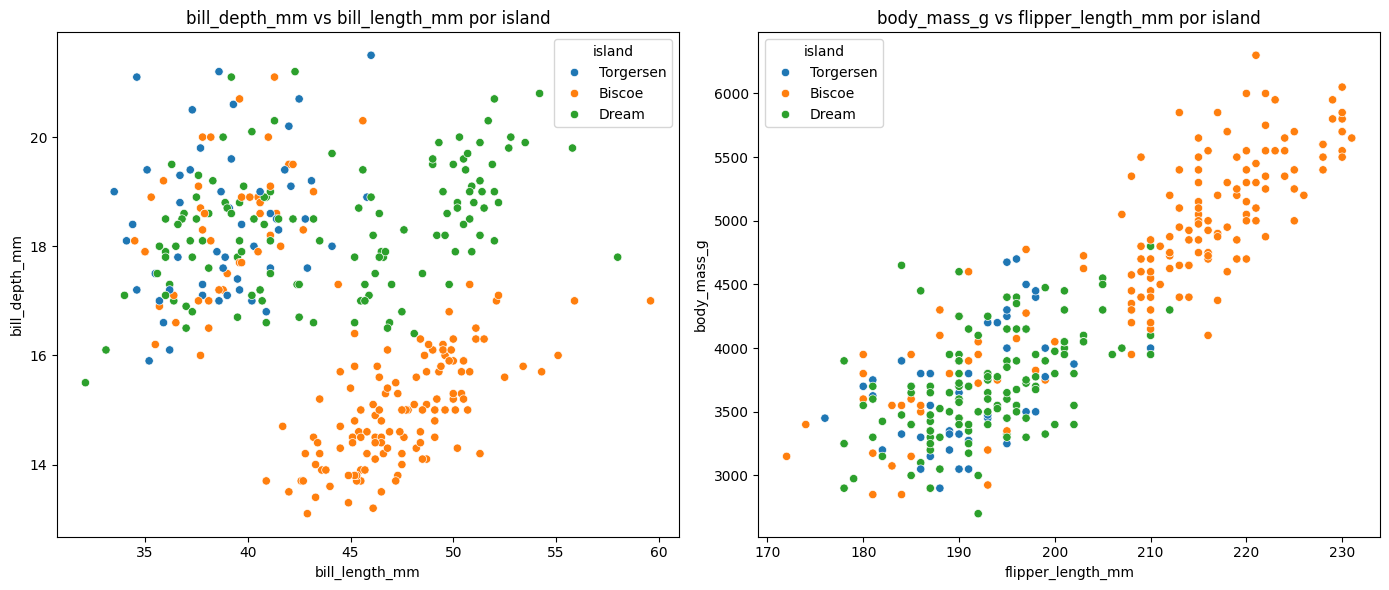


--- Scatterplots para variables numéricas con 'sex' como diferenciador ---


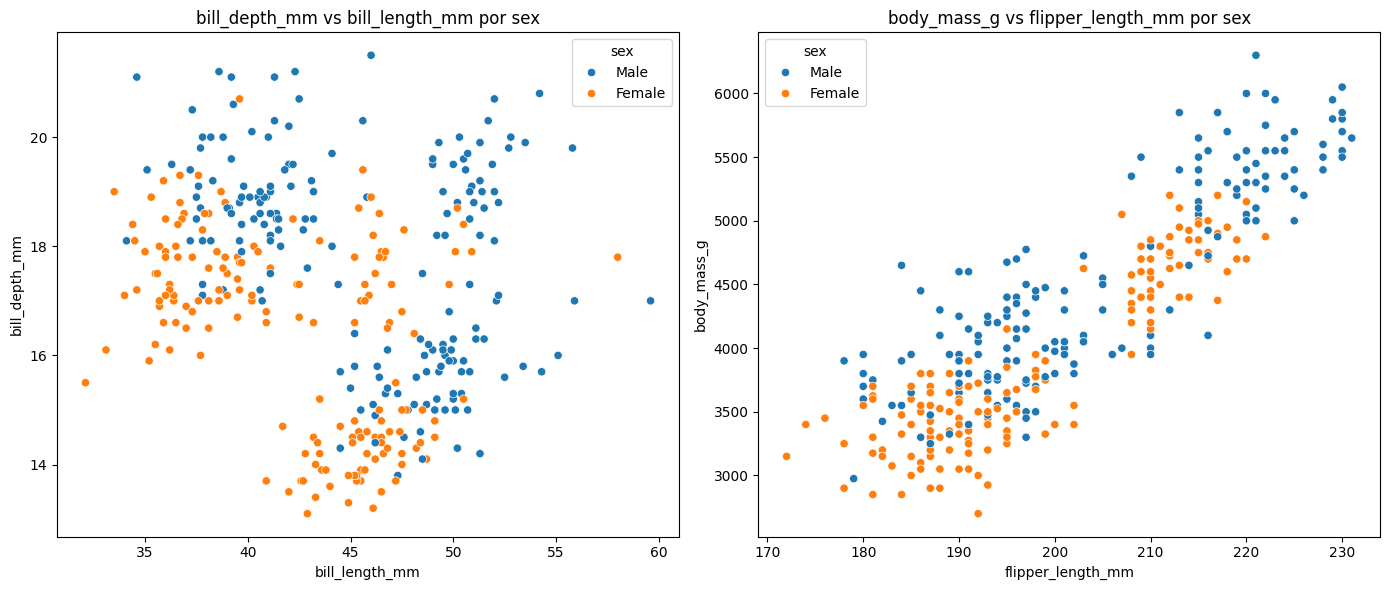

In [32]:
print("--- Matriz de correlación para variables numéricas ---")

# Seleccionar solo las columnas numéricas
numerical_df = df_penguins.select_dtypes(include=np.number)

# Calcular la matriz de correlación
corr_matrix_numerical = numerical_df.corr()

# Visualizar la matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_numerical, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

# Seleccionar las columnas categóricas
categorical_cols = ['species', 'island', 'sex']
# Elegir pares de variables numéricas para visualizar en scatterplots
numerical_vars_for_scatter = [('bill_length_mm', 'bill_depth_mm'), ('flipper_length_mm', 'body_mass_g')]

for cat_col in categorical_cols:
    print(f"\n--- Scatterplots para variables numéricas con '{cat_col}' como diferenciador ---")

    # Crear subplots para cada par de variables numéricas
    fig, axes = plt.subplots(nrows=1, ncols=len(numerical_vars_for_scatter), figsize=(len(numerical_vars_for_scatter)*7, 6))

    # Asegurarse de que `axes` sea siempre un array para iterar
    if len(numerical_vars_for_scatter) == 1:
        axes = [axes]

    for i, (x_var, y_var) in enumerate(numerical_vars_for_scatter):
        sns.scatterplot(data=df_penguins, x=x_var, y=y_var, hue=cat_col, ax=axes[i])
        axes[i].set_title(f'{y_var} vs {x_var} por {cat_col}')
        axes[i].set_xlabel(x_var)
        axes[i].set_ylabel(y_var)
        axes[i].legend(title=cat_col)

    plt.tight_layout()
    plt.show()

Mediante el mapa de correlación (heatmap) se identificó una fuerte relación positiva entre flipper_length_mm y body_mass_g, con un coeficiente cercano a 0.87, indicando que ambas variables presentan un comportamiento lineal significativo.

Asimismo, bill_length_mm mostró correlaciones moderadas con flipper_length_mm y body_mass_g, con valores aproximados de 0.66 y 0.60 respectivamente.

Complementando el análisis, se utilizaron gráficos de dispersión (scatterplot) para analizar la interacción entre variables numéricas y categóricas. A través de estas visualizaciones se observó que la especie Gentoo presenta mayores valores tanto en longitud de aleta como en masa corporal, mostrando una separación visual respecto a las demás especies.

Las demás relaciones observadas no presentaron patrones visuales suficientemente marcados como para considerarse altamente relevantes dentro del análisis exploratorio.

##Aprendizaje Estadistico
Regresion lineal simple

In [33]:
#Definimos x, y, basados en las observaciones
#se determinan flipper_lenght_mm y su relacion lineal con body_mass_mm

X = df_penguins[["flipper_length_mm"]]

y = df_penguins["body_mass_g"]

In [34]:
#comenzamos el entrenamiento y test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
#Creamos el modelo con sklearn

from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

In [36]:
#Entrenamiento del modelo con sklearn

modelo.fit(X_train, y_train)

LinearRegression()

In [38]:
#Vamos a ver los resultados del entrenamiento y test

predicciones = modelo.predict(X_test)
predicciones

array([4591.33658856, 4103.03976037, 3712.40229782, 3956.55071192,
       3907.7210291 , 4542.50690574, 4200.69912601, 3712.40229782,
       5226.12246521, 3321.76483527, 4103.03976037, 4884.31468548,
       4591.33658856, 4884.31468548, 4054.21007755, 3956.55071192,
       3614.74293218, 3907.7210291 , 3077.61642117, 3468.25388373,
       3810.06166346, 3468.25388373, 4737.82563702, 3517.08356654,
       3663.572615  , 4396.01785729, 4005.38039473, 3712.40229782,
       3810.06166346, 5226.12246521, 4151.86944319, 3272.93515245,
       3370.59451809, 4786.65531984, 3907.7210291 , 3224.10546963,
       4249.52880883, 4786.65531984, 3712.40229782, 3370.59451809,
       3858.89134628, 3810.06166346, 5128.46309957, 4542.50690574,
       3126.44610399, 3956.55071192, 5274.95214803, 5372.61151367,
       3663.572615  , 3907.7210291 , 4640.16627138, 3517.08356654,
       4640.16627138, 3810.06166346, 3370.59451809, 3517.08356654,
       3224.10546963, 5616.75992776, 5567.93024494, 3272.93515

In [39]:
#Evaluamos el modelo para ver que la desviacion que puede llegar a tener

from sklearn.metrics import r2_score, mean_absolute_error

print("R2:", r2_score(y_test, predicciones))
print("MAE:", mean_absolute_error(y_test, predicciones))

R2: 0.7820354165340795
MAE: 315.85971744954526


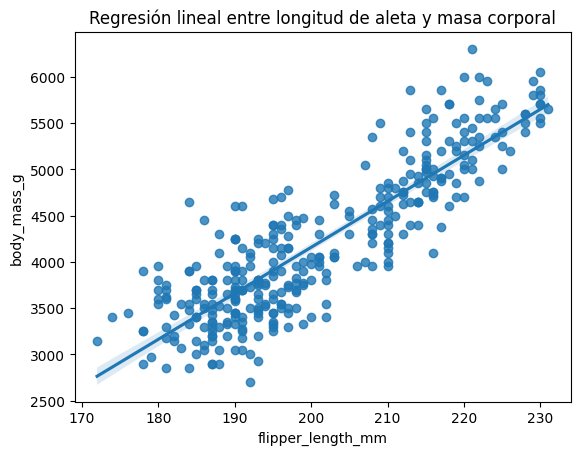

In [40]:
#Visualizamos la regresion
sns.regplot(
    data=df_penguins,
    x="flipper_length_mm",
    y="body_mass_g"
)

plt.title("Regresión lineal entre longitud de aleta y masa corporal")
plt.show()

El modelo de regresión lineal simple fue entrenado utilizando flipper_length_mm como variable predictora y body_mass_g como variable objetivo.

Los resultados obtenidos mostraron un coeficiente de determinación:

R
2
≈0.78

lo que indica que aproximadamente el 78% de la variabilidad de la masa corporal puede ser explicada por la longitud de la aleta.

Asimismo, el modelo presentó un error absoluto medio:

MAE≈315.86

indicando que, en promedio, las predicciones difieren alrededor de 316 gramos respecto a los valores reales.

En general, el modelo mostró un desempeño adecuado y confirmó la existencia de una relación lineal significativa entre la longitud de la aleta y la masa corporal de los pingüinos.